In [121]:
import os
if os.getcwd()[-11:] == "exploration":
    os.chdir('..')
import data.involcan.pull

### Find sensors of interest

In [122]:
import pandas as pd

files = pd.read_csv("data/involcan/metadata/available_files.csv")

In [123]:
# from datetime import datetime
starttime = pd.Timestamp('2021-09-12', tz='UTC')
endtime = pd.Timestamp('2021-09-26', tz='UTC')

files['start_time'] = pd.to_datetime(files['start_time'], utc=True)
files['end_time'] = pd.to_datetime(files['end_time'], utc=True)


eruption_files = files[(files['start_time']==starttime) | (files['end_time']==endtime) ]
eruption_sensors = pd.unique(eruption_files['sensor'])

In [124]:
print(f"There were {len(eruption_sensors)} measuring during the eruption")
print(f"They were: \n {eruption_sensors}")

There were 18 measuring during the eruption
They were: 
 ['PGAR' 'PBBA' 'PPMA' 'PMLU' 'PLPI' 'PTAB' 'PCOR' 'PA03' 'PA00' 'PA05'
 'PA09' 'PA01' 'PA04' 'PA02' 'PA08' 'PA06' 'PA07' 'PSAB']


In [125]:
sensors = pd.read_csv("data/involcan/metadata/stations_all.dat", sep=r"\s+",names=["station", "lat", "lon", "height"])
sensors_lp = sensors[
    ((sensors['lat']<28.871164) & (sensors['lat']>28.437932)) &
    ((sensors['lon']<-17.666590) & (sensors['lon']>-18.039439))
]


### Download the files of interest

In [138]:
(eruption_sensors).find

AttributeError: 'numpy.ndarray' object has no attribute 'find'

In [126]:
from datetime import datetime, timedelta
starttime = datetime(2021, 9, 15)
endtime = datetime(2021, 9, 20)
data_path = "/SCRATCH/TIC270/gsus/data/involcan/mseed/"
channels = ["HHE", "HHN", "HHZ"]
sensors = eruption_sensors

# data.involcan.pull.download_files(starttime, endtime, sensors, channels, data_path, user='seiscomp', verbose=True);

#### Discarded sensors:
- PA03: Missing data before the 18th of september

### Analyze the data

Reading 2021 data for sensor PPMA...


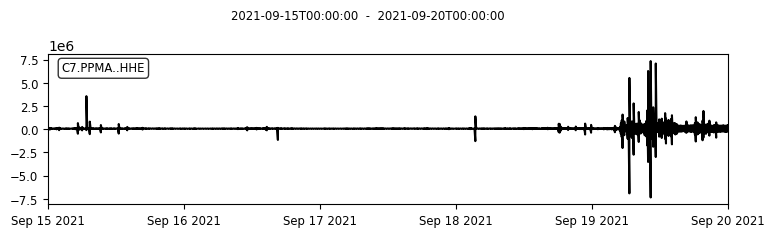

Reading 2021 data for sensor PMLU...


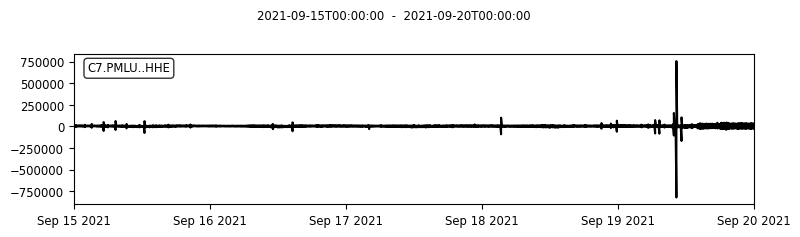

Reading 2021 data for sensor PLPI...


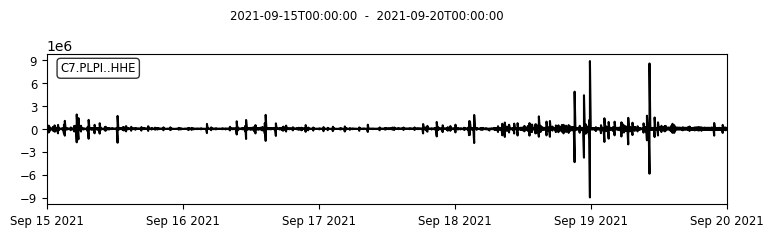

Reading 2021 data for sensor PTAB...


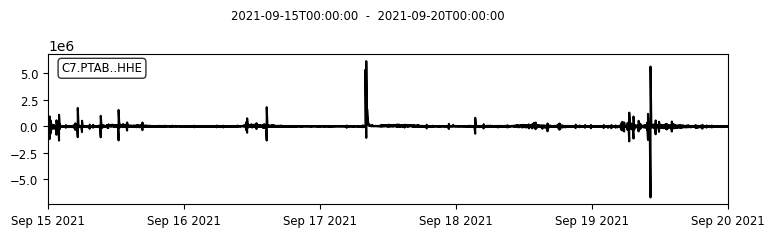

Reading 2021 data for sensor PCOR...


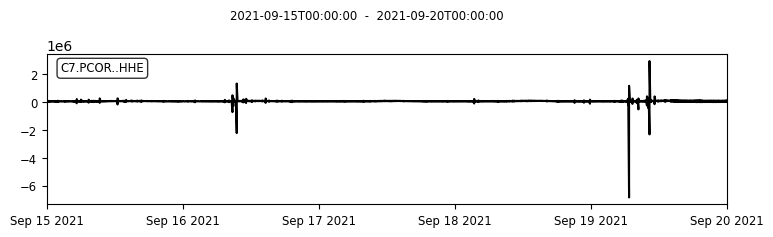

Reading 2021 data for sensor PA03...


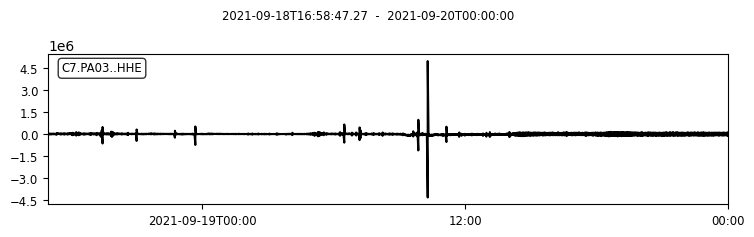

In [130]:
import obspy
from obspy.core import UTCDateTime

ST = []
sensor_ids = [2,3,4,5,6,7,]
for sensor_id in sensor_ids:
    print(f"Reading 2021 data for sensor {eruption_sensors[sensor_id]}...")
    st = obspy.read(f"{data_path}/C7.{eruption_sensors[sensor_id]}.*.2021.*",
                    starttime=UTCDateTime(starttime), endtime=UTCDateTime(endtime))
    st.merge()
    st.plot();
    ST.append(st)



#### Analyze frequencies with MESA

In [131]:
from msa.feature_extraction import features
from msa.visualization import plot

In [132]:
sr = st[0].stats.sampling_rate

window_length = 18 # s
window_samples = int(window_length*sr)
# shift = window_length*1000 #s
shift = 3600 #s
hop = int(shift*sr)

M = len(sensor_ids)
times = [[] for _ in range(M)]
freqs = [[] for _ in range(M)]
Sxxs  = [[] for _ in range(M)]

for i, sensor_id in enumerate(sensor_ids):

    signal = ST[i][0].data
    time, freq, Sxx = features.spectrogram(signal, sr, window_samples, hop, "blackman", "zeros", "linear",)
    times[i] = time[1:]
    freqs[i] = freq
    Sxxs[i]  = Sxx[:,1:]

IndexError: index 110 is out of bounds for axis 0 with size 31

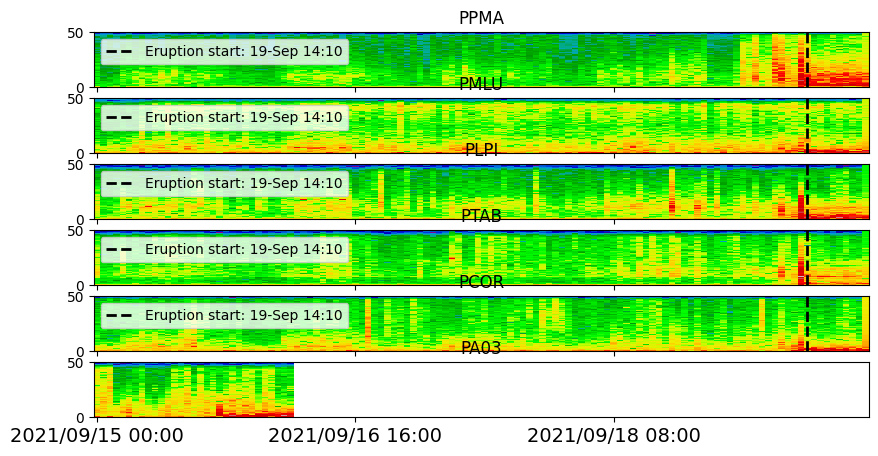

In [136]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# timeUTC = np.linspace(starttime, endtime, num= len(times), endpoint=False, dtype='datetime64[s]')#.astype("datetime64[m]")
timeUTC = np.arange(starttime, endtime, timedelta(seconds=shift), dtype='datetime64[s]')#.astype("datetime64[m]")

target_time = np.datetime64(datetime(2021, 9, 19, 14, 10), 'm')
eruption_idx = np.argmin(np.abs(timeUTC - target_time))

fig, ax = plt.subplots(M,1, figsize=(10,5), sharex=True)
if type(ax) != np.ndarray: ax = [ax]

skip:int = len(times[0])//3
locs = times[0][0::skip]
timeUTC_label = timeUTC[0::skip]
date_formatter = mdates.DateFormatter('%Y/%m/%d %H:%M')
formatted_labels = [date_formatter(mdates.date2num(t)) for t in timeUTC_label]

for i, sensor_id in enumerate(sensor_ids):
    ax[i].set_title(f"{eruption_sensors[sensor_id]}")
    plot.spectrogram(times[i], freqs[i], Sxxs[i], cmap="nipy_spectral", logscale=True, ax = ax[i]);

    ax[i].set_xticks(locs[:], labels=formatted_labels[:],fontsize=14);
    # ax.set_ylabel("Frequency (Hz)", fontsize=20)

    ax[i].axvline(x=times[i][eruption_idx], color='black', linestyle='--', linewidth=2, label='Eruption start: 19-Sep 14:10')
    ax[i].legend();

### PCA Visualizations

In [ ]:
# Data fusion
data = np.vstack(Sxxs).T

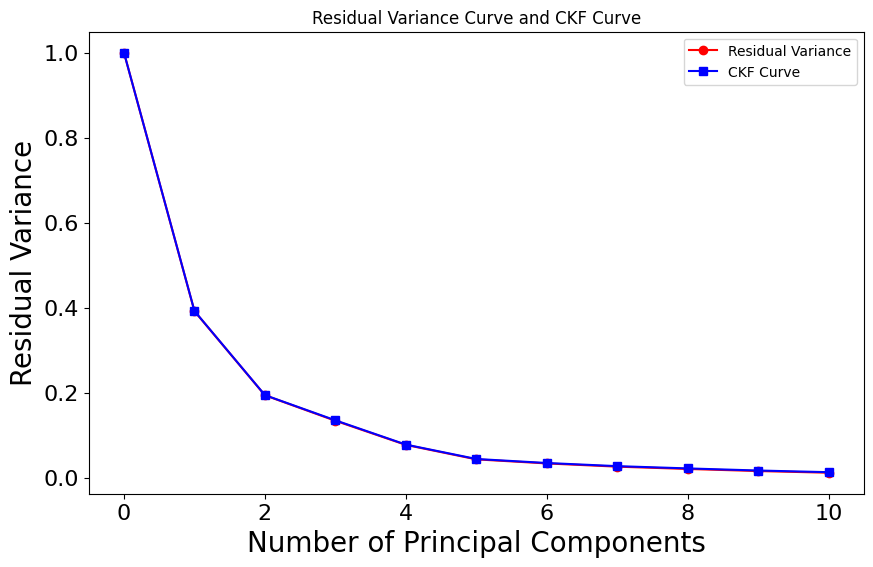

In [ ]:
import mspc_pca.plot
mspc_pca.plot.var_pca(data, 10);

In [ ]:
# !pip install scikit-learn

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

# mspc_pca.plot.biplot(data, pca, 1, 2, times[0], np.round(freq, 2), score_classes=times[0]);

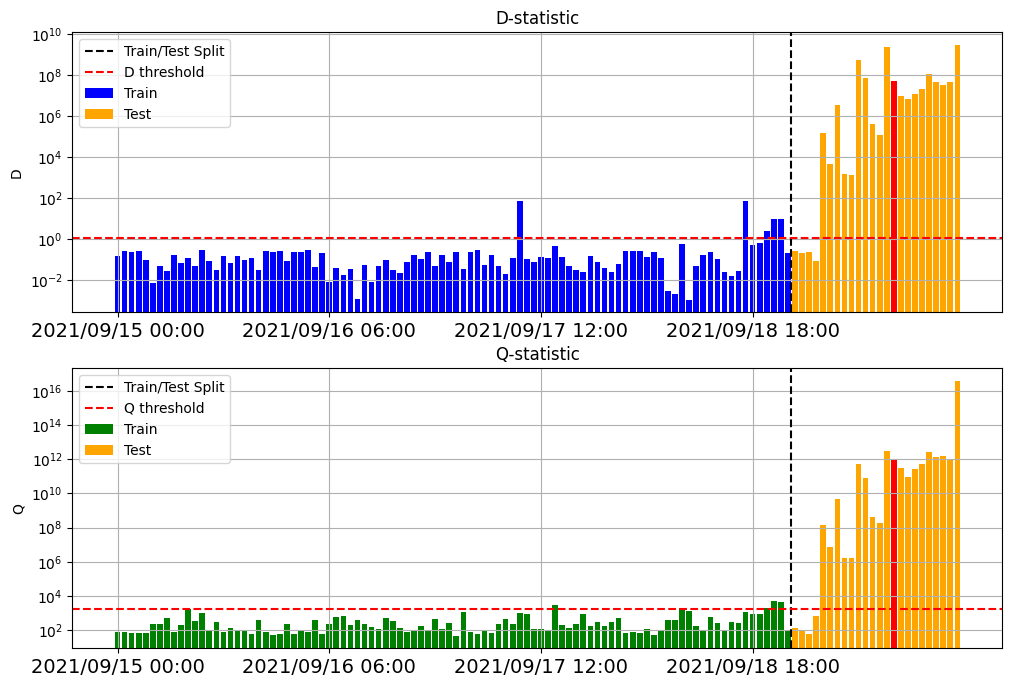

In [ ]:
import mspc_pca.mspc

day_id = np.argmin(np.abs(timeUTC - np.datetime64(datetime(2021, 9, 19), 'm')))

D_train, Q_train, D_test, Q_test, threshold_D, threshold_Q = mspc_pca.mspc.DQ_tt(data[:day_id], data[day_id:], 2, percentile_threshold=True, alpha=0.05)

fig, ax = mspc_pca.mspc.plot_DQ_tt(D_train, Q_train, D_test, Q_test, threshold_D, threshold_Q,
                                   logscale=True, event_index=[eruption_idx], 
                labels=None, plot_train=True, opacity=None, ax=None)

skip:int = len(timeUTC)//4
locs = np.arange(0, len(timeUTC))[0::skip]
timeUTC_label = timeUTC[0::skip]
date_formatter = mdates.DateFormatter('%Y/%m/%d %H:%M')
formatted_labels = [date_formatter(mdates.date2num(t)) for t in timeUTC_label]
ax[0].set_xticks(locs[:], labels=formatted_labels[:],fontsize=14);
ax[1].set_xticks(locs[:], labels=formatted_labels[:],fontsize=14);